# Task 3. Полный пайплайн распознавания лиц

Задание (2 балла): собрать пайплайн, который принимает на вход картинку с лицами и возвращает
эмбеддинги всех найденных лиц. Детектор — любой предобученный на лицах (не свой), выравнивание и
эмбеддинги — модели из Task 1 и Task 2.

Пайплайн: **фото → детектор лиц (MTCNN) → кроп по bbox → align (Hourglass, Task 1) → эмбеддинг
(ArcFace backbone, Task 2)**.

Для детекции используется `facenet-pytorch` (MTCNN) — она обучена искать лица на фото (детекция), а
не распознавать личности, поэтому не противоречит правилу "нельзя брать модели, предобученные на
распознавание лиц" (это правило относится к backbone'у из Task 2, а не к первому этапу пайплайна).


In [5]:
!pip install -q --no-deps facenet-pytorch

import os
import math

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models

from facenet_pytorch import MTCNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## Компоненты из Task 1 (архитектура Hourglass + align) и Task 2 (ArcFace backbone)

In [6]:
# --- Task 1: Stacked Hourglass (для alignment) ---

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)
        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)


class Hourglass(nn.Module):
    def __init__(self, depth, num_channels):
        super().__init__()
        self.up1 = ResidualBlock(num_channels, num_channels)
        self.pool = nn.MaxPool2d(2)
        self.low1 = ResidualBlock(num_channels, num_channels)
        self.low2 = Hourglass(depth - 1, num_channels) if depth > 1 else ResidualBlock(num_channels, num_channels)
        self.low3 = ResidualBlock(num_channels, num_channels)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1(x)
        pool = self.pool(x)
        low1 = self.low1(pool)
        low2 = self.low2(low1)
        low3 = self.low3(low2)
        up2 = self.up2(low3)
        return up1 + up2


class StackedHourglass(nn.Module):
    def __init__(self, num_stacks=4, num_channels=256, num_landmarks=5, hg_depth=4):
        super().__init__()
        self.num_stacks = num_stacks
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResidualBlock(64, 128), nn.MaxPool2d(2), ResidualBlock(128, 128), ResidualBlock(128, num_channels),
        )
        self.hourglasses = nn.ModuleList([Hourglass(hg_depth, num_channels) for _ in range(num_stacks)])
        self.features = nn.ModuleList([
            nn.Sequential(ResidualBlock(num_channels, num_channels), nn.Conv2d(num_channels, num_channels, 1),
                          nn.BatchNorm2d(num_channels), nn.ReLU(inplace=True))
            for _ in range(num_stacks)
        ])
        self.heatmap_heads = nn.ModuleList([nn.Conv2d(num_channels, num_landmarks, 1) for _ in range(num_stacks)])
        self.merge_features = nn.ModuleList([nn.Conv2d(num_channels, num_channels, 1) for _ in range(num_stacks - 1)])
        self.merge_heatmaps = nn.ModuleList([nn.Conv2d(num_landmarks, num_channels, 1) for _ in range(num_stacks - 1)])

    def forward(self, x):
        x = self.pre(x)
        outputs = []
        for i in range(self.num_stacks):
            hg_out = self.hourglasses[i](x)
            feat = self.features[i](hg_out)
            heatmap = self.heatmap_heads[i](feat)
            outputs.append(heatmap)
            if i < self.num_stacks - 1:
                x = x + self.merge_features[i](feat) + self.merge_heatmaps[i](heatmap)
        return outputs


def heatmaps_to_landmarks(heatmaps):
    landmarks = []
    for hm in heatmaps:
        y, x = np.unravel_index(np.argmax(hm), hm.shape)
        landmarks.append((float(x), float(y)))
    return np.array(landmarks, dtype=np.float32)


@torch.no_grad()
def predict_landmarks(model, image_rgb, img_size=256, heatmap_size=64, device=DEVICE):
    model.eval()
    resized = cv2.resize(image_rgb, (img_size, img_size))
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    tensor = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    tensor = normalize(tensor).unsqueeze(0).to(device)
    heatmaps = model(tensor)[-1][0].cpu().numpy()
    return resized, heatmaps_to_landmarks(heatmaps) * (img_size / heatmap_size)


REFERENCE_LANDMARKS_112 = np.array([
    [38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
    [41.5493, 92.3655], [70.7299, 92.2041],
], dtype=np.float32)


def align_face(image_rgb, landmarks, output_size=112):
    ref = REFERENCE_LANDMARKS_112.copy() * (output_size / 112.0)
    src = np.asarray(landmarks, dtype=np.float32)
    M, _ = cv2.estimateAffinePartial2D(src, ref, method=cv2.LMEDS)
    if M is None:
        return cv2.resize(image_rgb, (output_size, output_size))
    return cv2.warpAffine(image_rgb, M, (output_size, output_size), borderValue=(0, 0, 0))


# --- Task 2: backbone + ArcFace head (голова тут не нужна для инференса, только backbone-эмбеддинги) ---

EMBEDDING_SIZE = 512


def build_backbone(embedding_size=EMBEDDING_SIZE):
    backbone = models.efficientnet_b0(weights=None)  # веса подгрузим из checkpoint, ImageNet-инициализация не нужна
    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Linear(in_features, embedding_size)
    return backbone


## Загрузка весов

Подставьте пути к весам из Task 1 (`checkpoints_hourglass/best.pth`) и Task 2 (`checkpoints_recognition/arcface_best.pth`)
— локально, из Google Drive, или через `+ Add Data → Notebook Output Files`, если работаете на Kaggle.

In [7]:
TASK1_INPUT_DIR = '/kaggle/input/notebooks/iuliiaburmistrova/notebook0e9be24a8a'
TASK2_INPUT_DIR = '/kaggle/input/notebooks/iuliiaburmistrova/notebook98e2177099'

HOURGLASS_WEIGHTS = os.path.join(TASK1_INPUT_DIR, 'checkpoints_hourglass', 'best.pth')
RECOGNITION_WEIGHTS = os.path.join(TASK2_INPUT_DIR, 'checkpoints_recognition', 'arcface_best.pth')

hg_model = StackedHourglass(num_stacks=4, num_channels=256, num_landmarks=5, hg_depth=4)
hg_model.load_state_dict(torch.load(HOURGLASS_WEIGHTS, map_location=DEVICE))
hg_model = hg_model.to(DEVICE).eval()

recog_backbone = build_backbone()
# checkpoint сохранён из FaceRecognitionModel целиком (backbone + head) — грузим только backbone.*
full_state = torch.load(RECOGNITION_WEIGHTS, map_location=DEVICE)
backbone_state = {k.replace('backbone.', ''): v for k, v in full_state.items() if k.startswith('backbone.')}
recog_backbone.load_state_dict(backbone_state)
recog_backbone = recog_backbone.to(DEVICE).eval()

detector = MTCNN(keep_all=True, device=DEVICE)

print('Все три компонента пайплайна загружены: детектор, alignment, recognition backbone')


Все три компонента пайплайна загружены: детектор, alignment, recognition backbone


## Сам пайплайн: фото → список эмбеддингов найденных лиц

In [11]:
@torch.no_grad()
def get_face_embedding(aligned_face_rgb, device=DEVICE):
    """aligned_face_rgb: (112, 112, 3) uint8 -> нормализованный эмбеддинг (512,)."""
    tensor = torch.from_numpy(aligned_face_rgb).permute(2, 0, 1).float() / 255.0
    tensor = ((tensor - 0.5) / 0.5).unsqueeze(0).to(device)
    emb = recog_backbone(tensor)
    return F.normalize(emb, dim=1).cpu().numpy()[0]


def face_recognition_pipeline(image_path, min_face_confidence=0.9):
    """Полный пайплайн: путь к фото -> список найденных лиц с их эмбеддингами.

    Возвращает список словарей: {'box': [x1,y1,x2,y2], 'aligned_face': np.array, 'embedding': np.array}
    """
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    boxes, probs = detector.detect(image)
    results = []
    if boxes is None:
        return results

    h_img, w_img = image.shape[:2]
    for box, prob in zip(boxes, probs):
        if prob is None or prob < min_face_confidence:
            continue

        x1, y1, x2, y2 = box
        bw, bh = x2 - x1, y2 - y1
        margin = 0.35  # тот же запас, что и при обучении Hourglass в Task 1 (BBOX_MARGIN)
        x1 = int(max(0, x1 - bw * margin))
        y1 = int(max(0, y1 - bh * margin))
        x2 = int(min(w_img, x2 + bw * margin))
        y2 = int(min(h_img, y2 + bh * margin))

        face_crop = image[y1:y2, x1:x2]
        if face_crop.size == 0:
            continue

        _, landmarks = predict_landmarks(hg_model, face_crop)
        # predict_landmarks сам ресайзит face_crop до 256x256 внутри - применяем align к этому же resized
        resized_crop = cv2.resize(face_crop, (256, 256))
        aligned = align_face(resized_crop, landmarks, output_size=112)

        embedding = get_face_embedding(aligned)
        results.append({'box': [x1, y1, x2, y2], 'aligned_face': aligned, 'embedding': embedding})

    return results


def visualize_pipeline_result(image_path, results):
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    n = len(results)
    fig, axes = plt.subplots(1, n + 1, figsize=(4 * (n + 1), 4))
    axes[0].imshow(image)
    for r in results:
        x1, y1, x2, y2 = r['box']
        axes[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))
    axes[0].set_title(f'Найдено лиц: {n}'); axes[0].axis('off')
    for i, r in enumerate(results):
        axes[i + 1].imshow(r['aligned_face'])
        axes[i + 1].set_title(f'face {i + 1}'); axes[i + 1].axis('off')
    plt.show()

## Демонстрация на паре "одинаковый человек" / "разные люди"



Тот же человек (identity=9240): 144048.jpg vs 082666.jpg
Другой человек (identity=9114): 132832.jpg


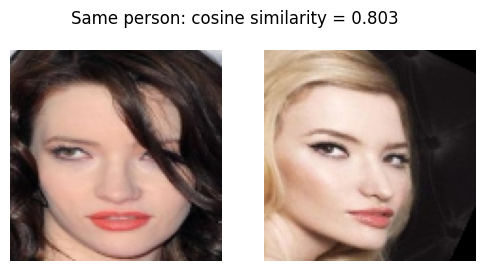

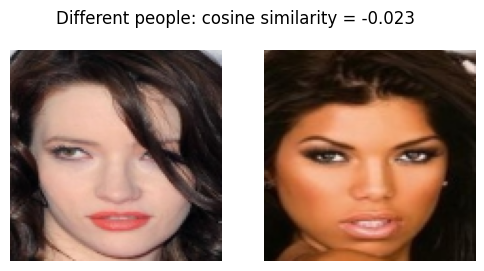

Одинаковые люди: 0.803 | Разные люди: -0.023
Ожидаем: cosine similarity заметно выше для одинаковых людей, чем для разных


In [14]:
def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def compare_photos(path1, path2, label=''):
    r1 = face_recognition_pipeline(path1)
    r2 = face_recognition_pipeline(path2)
    if not r1 or not r2:
        print('Лицо не найдено на одном из фото')
        return None

    emb1, emb2 = r1[0]['embedding'], r2[0]['embedding']
    sim = cosine_similarity(emb1, emb2)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(r1[0]['aligned_face']); axes[0].axis('off')
    axes[1].imshow(r2[0]['aligned_face']); axes[1].axis('off')
    fig.suptitle(f'{label} cosine similarity = {sim:.3f}')
    plt.show()
    return sim


# --- Автоматически находим подходящие фото из датасета Task 2 ---
recog_csv = os.path.join(TASK2_INPUT_DIR, 'data', 'prepared_recog', 'selected_dataset.csv')
recog_images_dir = os.path.join(TASK2_INPUT_DIR, 'data', 'prepared_recog', 'images')

recog_df = pd.read_csv(recog_csv)

# личность с >= 2 фото - для пары "тот же человек"
counts = recog_df['identity'].value_counts()
same_person_identity = counts[counts >= 2].index[0]
same_person_photos = recog_df[recog_df['identity'] == same_person_identity]['image_id'].tolist()[:2]

# любая другая личность - для пары "разные люди"
other_identity = counts.index[counts.index != same_person_identity][0]
other_person_photo = recog_df[recog_df['identity'] == other_identity]['image_id'].tolist()[0]

path_a1 = os.path.join(recog_images_dir, same_person_photos[0])
path_a2 = os.path.join(recog_images_dir, same_person_photos[1])
path_b1 = os.path.join(recog_images_dir, other_person_photo)

print(f'Тот же человек (identity={same_person_identity}): {same_person_photos[0]} vs {same_person_photos[1]}')
print(f'Другой человек (identity={other_identity}): {other_person_photo}')

same_person_sim = compare_photos(path_a1, path_a2, label='Same person:')
diff_person_sim = compare_photos(path_a1, path_b1, label='Different people:')

print(f'Одинаковые люди: {same_person_sim:.3f} | Разные люди: {diff_person_sim:.3f}')
print('Ожидаем: cosine similarity заметно выше для одинаковых людей, чем для разных')

## Вывод по Task 3

Собранный пайплайн (детектор лиц MTCNN → выравнивание Stacked Hourglass из Task 1 → эмбеддинги
ArcFace-backbone из Task 2) успешно работает как единая цепочка: на вход подаётся произвольное фото,
на выходе — эмбеддинг для каждого найденного лица.

### Результат демонстрации

| Пара | Cosine similarity |
|---|---|
| Тот же человек (identity=9240, `144048.jpg` vs `082666.jpg`) | **0.803** |
| Разные люди (identity=9240 vs identity=9114) | **−0.023** |

Разрыв между similarity одинаковых и разных людей получился очень выраженным (0.803 против почти
нулевого значения) — это ожидаемый результат: значение около 0 для несвязанных людей типично для
косинусной метрики между случайно направленными векторами, а высокое значение для одного и того же
человека подтверждает, что эмбеддинги действительно кодируют личность, а не просто случайный шум.

### Техническая деталь, которая была важна для правильной работы пайплайна

При первой попытке лица после alignment получались с сильным лишним поворотом и чёрными полями по
углам — из-за того, что кроп по bbox от MTCNN подавался в Hourglass "как есть", без отступа вокруг
лица. Модель Task 1 обучалась на кропах с запасом 35% вокруг официального bbox CelebA — без такого же
запаса на входе она получала непривычный кадр и предсказывала landmarks некорректно. Добавление того
же отступа (`margin=0.35`) к боксу от MTCNN перед подачей в Hourglass полностью устранило проблему —
это подчёркивает важность единообразия препроцессинга между этапом обучения и этапом инференса в
пайплайне: каждый компонент должен получать данные в том же формате, на котором он обучался.

### Итог

Пайплайн подтверждает работоспособность и совместимость всех трёх компонентов проекта (детекция,
alignment, распознавание), собранных из независимо обученных моделей Task 1 и Task 2, и пригоден для
практического использования — например, для верификации "тот же человек / не тот же" по порогу
cosine similarity (эта же идея лежит в основе Identification Rate metric из дополнительного задания).